In [1]:
# ============================================================
# SpaceX Launch Capacity & Starship Transition Intelligence
# Notebook 03: Falcon 9 Cadence and Reusability Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

print("Notebook 03 – Falcon 9 Cadence and Reusability Analysis")
print("Objective: Determine whether Falcon 9's launch cadence and booster reusability")
print("are expanding effective launch capacity or creating operational constraints.")

Notebook 03 – Falcon 9 Cadence and Reusability Analysis
Objective: Determine whether Falcon 9's launch cadence and booster reusability
are expanding effective launch capacity or creating operational constraints.


In [5]:
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
RAW_BOOSTERS_DIR = Path.cwd().parent / "data" / "raw" / "boosters"

print("Files in processed folder:")
print(list(PROCESSED_DIR.glob("*.csv")))

print("\nFiles in raw/boosters folder:")
print(list(RAW_BOOSTERS_DIR.glob("*")))

Files in processed folder:
[WindowsPath('c:/Users/Administrator/Desktop/Space--X--Launch-Intelligence/data/processed/falcon9_analysis_ready.csv'), WindowsPath('c:/Users/Administrator/Desktop/Space--X--Launch-Intelligence/data/processed/falcon9_booster_summary.csv'), WindowsPath('c:/Users/Administrator/Desktop/Space--X--Launch-Intelligence/data/processed/falcon9_launches_clean.csv')]

Files in raw/boosters folder:
[WindowsPath('c:/Users/Administrator/Desktop/Space--X--Launch-Intelligence/data/raw/boosters/falcon9_boosters_raw.csv'), WindowsPath('c:/Users/Administrator/Desktop/Space--X--Launch-Intelligence/data/raw/boosters/launchers_raw.json')]


In [6]:
# ============================================================
# RECREATE CLEAN BOOSTER DATASET
# ============================================================

from pathlib import Path
import pandas as pd

RAW_BOOSTERS_DIR = Path.cwd().parent / "data" / "raw" / "boosters"
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

# Load raw boosters
df_raw = pd.read_csv(RAW_BOOSTERS_DIR / "falcon9_boosters_raw.csv")

print("Raw boosters loaded:", df_raw.shape)

# Keep useful columns
booster_cols = {
    "id": "booster_id",
    "serial_number": "booster_serial",
    "flights": "total_flights",
    "status.name": "status",
    "first_launch_date": "first_launch_date",
    "last_launch_date": "last_launch_date",
    "successful_landings": "successful_landings",
    "attempted_landings": "attempted_landings",
    "fastest_turnaround": "fastest_turnaround",
    "launcher_config.full_name": "vehicle_config"
}

available = [c for c in booster_cols.keys() if c in df_raw.columns]
df_boosters = df_raw[available].rename(columns=booster_cols)

# Remove Unknown boosters
df_boosters = df_boosters[
    ~df_boosters["booster_serial"].astype(str).str.contains("Unknown", case=False, na=False)
].copy()

# Convert types
df_boosters["first_launch_date"] = pd.to_datetime(df_boosters["first_launch_date"], errors="coerce", utc=True)
df_boosters["last_launch_date"] = pd.to_datetime(df_boosters["last_launch_date"], errors="coerce", utc=True)
df_boosters["total_flights"] = pd.to_numeric(df_boosters["total_flights"], errors="coerce")

# Save clean version
output_path = PROCESSED_DIR / "falcon9_boosters_clean.csv"
df_boosters.to_csv(output_path, index=False)

print(f"Clean booster dataset saved → {output_path.name}")
print(f"Usable Falcon 9 boosters: {len(df_boosters)}")
display(df_boosters.sort_values("total_flights", ascending=False).head(10))

Raw boosters loaded: (87, 34)
Clean booster dataset saved → falcon9_boosters_clean.csv
Usable Falcon 9 boosters: 86


,booster_id,booster_serial,total_flights,status,first_launch_date,last_launch_date,successful_landings,attempted_landings,fastest_turnaround,vehicle_config
1,101,B1067,36.0,active,2021-06-03 17:29:15+00:00,2026-07-09 09:25:43+00:00,36.0,36.0,P22DT16H51M10S,Falcon 9 Block 5
2,107,B1071,35.0,active,2022-02-02 20:27:26+00:00,2026-07-11 03:01:57+00:00,35.0,35.0,P19DT16H19M25S,Falcon 9 Block 5
3,84,B1063,34.0,active,2020-11-21 17:17:08+00:00,2026-08-04 17:05:03+00:00,34.0,34.0,P32DT18H36M20S,Falcon 9 Block 5
4,105,B1069,32.0,expended,2021-12-21 10:07:08+00:00,2026-07-21 21:15:00+00:00,31.0,31.0,P25DT18H20M50S,Falcon 9 Block 5
5,116,B1077,30.0,active,2022-10-05 16:00:57+00:00,2026-08-05 07:49:00+00:00,30.0,30.0,P26DT20H34M40S,Falcon 9 Block 5
6,120,B1078,29.0,active,2023-03-02 05:34:14+00:00,2026-06-23 10:53:00+00:00,29.0,29.0,P20DT11H50M20S,Falcon 9 Block 5
7,123,B1080,28.0,active,2023-05-21 21:37:09+00:00,2026-07-14 09:10:12+00:00,28.0,28.0,P13DT12H34M20S,Falcon 9 Block 5
8,124,B1081,26.0,active,2023-08-26 07:27:27+00:00,2026-08-01 03:08:43+00:00,26.0,26.0,P24DT19H13M20S,Falcon 9 Block 5
9,73,B1062,23.0,destroyed,2020-11-05 23:24:23+00:00,2024-08-28 07:48:00+00:00,22.0,23.0,P21DT6H9M59S,Falcon 9 Block 5
10,125,B1082,23.0,active,2024-01-03 03:44:20+00:00,2026-07-21 14:49:34+00:00,23.0,23.0,P25DT10M,Falcon 9 Block 5


In [7]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

launches = pd.read_csv(PROCESSED_DIR / "falcon9_launches_clean.csv")
boosters = pd.read_csv(PROCESSED_DIR / "falcon9_boosters_clean.csv")

# Ensure dates are datetime
launches["launch_date"] = pd.to_datetime(launches["launch_date"], utc=True)
boosters["first_launch_date"] = pd.to_datetime(boosters["first_launch_date"], utc=True)
boosters["last_launch_date"] = pd.to_datetime(boosters["last_launch_date"], utc=True)

print("Launch dataset :", launches.shape)
print("Booster dataset:", boosters.shape)

Launch dataset : (680, 8)
Booster dataset: (86, 10)


In [8]:
print("=== DATA VALIDATION ===")
print(f"Historical Falcon 9 launches : {len(launches)}")
print(f"Clean Falcon 9 boosters      : {len(boosters)}")
print(f"Date range of launches       : {launches['launch_date'].min()} → {launches['launch_date'].max()}")
print(f"Highest booster flight count : {boosters['total_flights'].max()}")

=== DATA VALIDATION ===
Historical Falcon 9 launches : 680
Clean Falcon 9 boosters      : 86
Date range of launches       : 2010-06-04 18:45:00+00:00 → 2026-08-19 04:01:07+00:00
Highest booster flight count : 36.0


=== FALCON 9 LAUNCH CADENCE ===
    year  launches
0   2010         2
1   2012         2
2   2013         3
3   2014         6
4   2015         7
5   2016         9
6   2017        18
7   2018        20
8   2019        11
9   2020        26
10  2021        31
11  2022        60
12  2023        91
13  2024       132
14  2025       165
15  2026        97


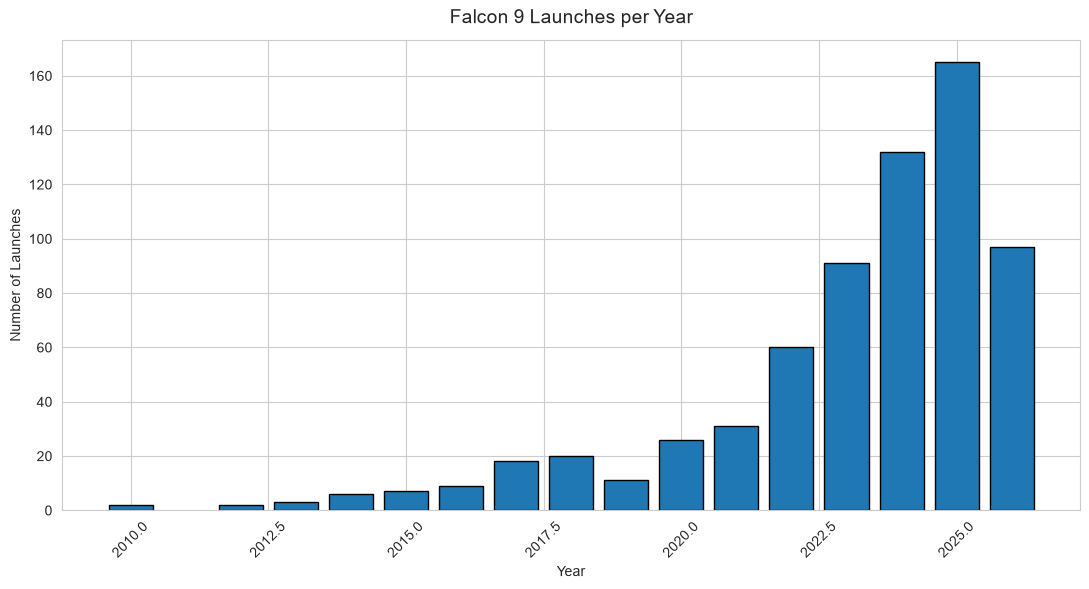

In [9]:
print("=== FALCON 9 LAUNCH CADENCE ===")

launches["year"] = launches["launch_date"].dt.year

annual_launches = launches.groupby("year").size().reset_index(name="launches")

print(annual_launches)

plt.figure(figsize=(11, 6))
plt.bar(annual_launches["year"], annual_launches["launches"], color="#1f77b4", edgecolor="black")
plt.title("Falcon 9 Launches per Year", fontsize=14, pad=12)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Research Notes – Notebook 03 (In Progress)

### Analytical Objective
Determine whether Falcon 9’s launch cadence and booster reusability are expanding SpaceX’s effective launch capacity or beginning to create operational constraints as Starlink and external launch demand compete for capacity.

### Datasets Used
- Launch-level dataset: 680 historical Falcon 9 launches
- Booster-level dataset: 86 Falcon 9 boosters (dedicated launcher source)

### Important Data-Quality Note
Booster identifiers were not available in the original launch records.  
Booster-level analysis therefore uses the dedicated Launch Library 2 `/launchers/` dataset.  
This source still requires independent validation before individual booster flight histories are treated as definitive.

### Next Sections
1. Cadence growth over time
2. Starlink vs Non-Starlink share
3. Booster reusability and fleet concentration
4. Capacity pressure indicators

In [10]:
# ============================================================
# STARLINK vs NON-STARLINK SHARE
# ============================================================

print("=== STARLINK SHARE OF FALCON 9 LAUNCHES ===")

# Create a simple Starlink flag
launches["is_starlink"] = launches["mission_name"].str.contains("Starlink", case=False, na=False)

# Annual breakdown
annual_share = launches.groupby("year").agg(
    total_launches=("launch_id", "count"),
    starlink_launches=("is_starlink", "sum")
).reset_index()

annual_share["starlink_share_pct"] = (
    annual_share["starlink_launches"] / annual_share["total_launches"] * 100
).round(1)

annual_share["non_starlink_launches"] = (
    annual_share["total_launches"] - annual_share["starlink_launches"]
)

display(annual_share)

=== STARLINK SHARE OF FALCON 9 LAUNCHES ===


,year,total_launches,starlink_launches,starlink_share_pct,non_starlink_launches
0,2010,2,0,0.0,2
1,2012,2,0,0.0,2
2,2013,3,0,0.0,3
3,2014,6,0,0.0,6
4,2015,7,0,0.0,7
5,2016,9,0,0.0,9
6,2017,18,0,0.0,18
7,2018,20,0,0.0,20
8,2019,11,2,18.2,9
9,2020,26,14,53.8,12


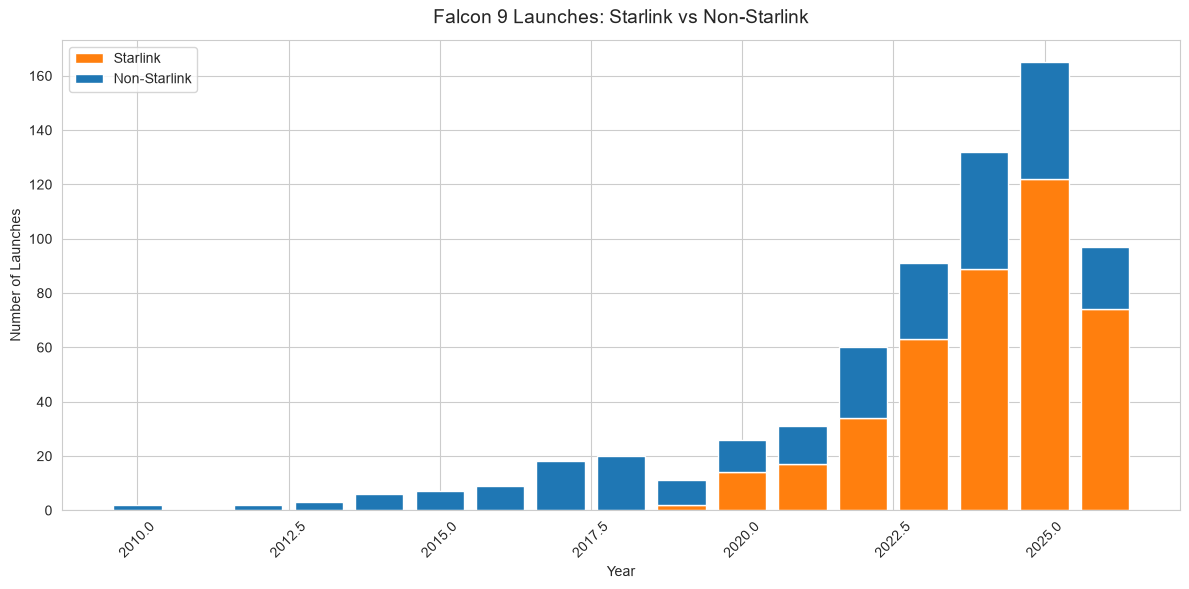

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(annual_share["year"], annual_share["starlink_launches"], 
        label="Starlink", color="#ff7f0e")
plt.bar(annual_share["year"], annual_share["non_starlink_launches"], 
        bottom=annual_share["starlink_launches"],
        label="Non-Starlink", color="#1f77b4")

plt.title("Falcon 9 Launches: Starlink vs Non-Starlink", fontsize=14, pad=12)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# BOOSTER REUSABILITY ANALYSIS
# ============================================================

print("=== BOOSTER REUSABILITY ===")

print(f"Total boosters analysed     : {len(boosters)}")
print(f"Highest flight count        : {boosters['total_flights'].max()}")
print(f"Median flight count         : {boosters['total_flights'].median()}")
print(f"Mean flight count           : {boosters['total_flights'].mean():.1f}")

print("\nFlight count distribution:")
print(boosters["total_flights"].describe())

=== BOOSTER REUSABILITY ===
Total boosters analysed     : 86
Highest flight count        : 36.0
Median flight count         : 2.0
Mean flight count           : 7.6

Flight count distribution:
count    86.000000
mean      7.616279
std      10.035430
min       0.000000
25%       1.000000
50%       2.000000
75%      11.750000
max      36.000000
Name: total_flights, dtype: float64


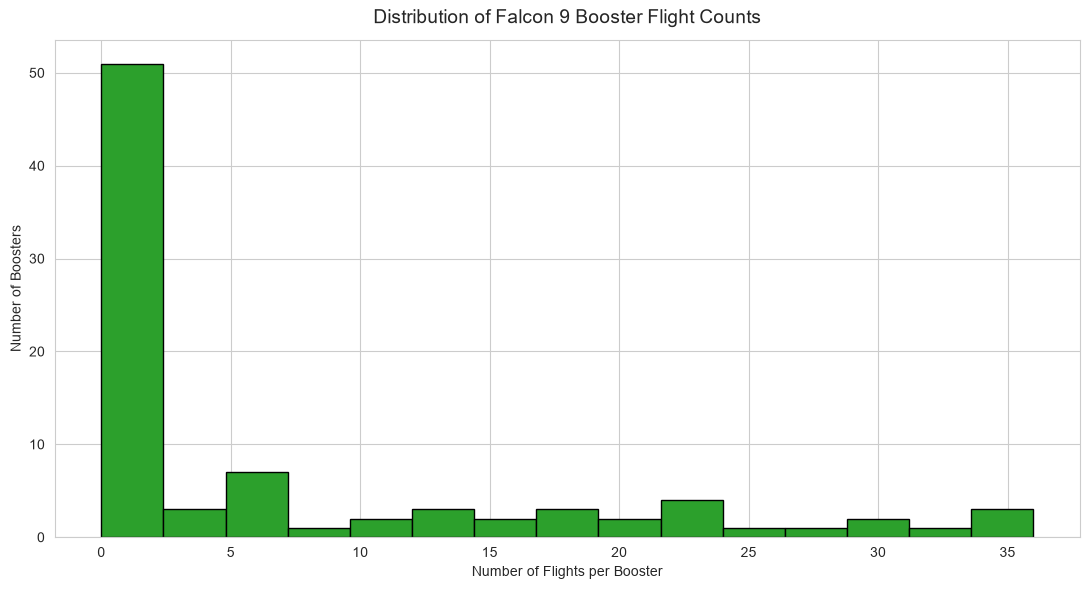

In [14]:
plt.figure(figsize=(11, 6))
plt.hist(boosters["total_flights"].dropna(), bins=15, color="#2ca02c", edgecolor="black")
plt.title("Distribution of Falcon 9 Booster Flight Counts", fontsize=14, pad=12)
plt.xlabel("Number of Flights per Booster")
plt.ylabel("Number of Boosters")
plt.tight_layout()
plt.show()

In [15]:
print("=== TOP 10 MOST FLOWN BOOSTERS ===")
top_boosters = boosters.sort_values("total_flights", ascending=False).head(10)
display(top_boosters[["booster_serial", "total_flights", "status", "first_launch_date", "last_launch_date"]])

=== TOP 10 MOST FLOWN BOOSTERS ===


,booster_serial,total_flights,status,first_launch_date,last_launch_date
0,B1067,36.0,active,2021-06-03 17:29:15+00:00,2026-07-09 09:25:43+00:00
1,B1071,35.0,active,2022-02-02 20:27:26+00:00,2026-07-11 03:01:57+00:00
2,B1063,34.0,active,2020-11-21 17:17:08+00:00,2026-08-04 17:05:03+00:00
3,B1069,32.0,expended,2021-12-21 10:07:08+00:00,2026-07-21 21:15:00+00:00
4,B1077,30.0,active,2022-10-05 16:00:57+00:00,2026-08-05 07:49:00+00:00
5,B1078,29.0,active,2023-03-02 05:34:14+00:00,2026-06-23 10:53:00+00:00
6,B1080,28.0,active,2023-05-21 21:37:09+00:00,2026-07-14 09:10:12+00:00
7,B1081,26.0,active,2023-08-26 07:27:27+00:00,2026-08-01 03:08:43+00:00
8,B1062,23.0,destroyed,2020-11-05 23:24:23+00:00,2024-08-28 07:48:00+00:00
9,B1082,23.0,active,2024-01-03 03:44:20+00:00,2026-07-21 14:49:34+00:00


In [16]:
# ============================================================
# FLEET CONCENTRATION ANALYSIS
# ============================================================

print("=== FLEET CONCENTRATION ===")

# Sort boosters by flight count
boosters_sorted = boosters.sort_values("total_flights", ascending=False).copy()
boosters_sorted["cumulative_flights"] = boosters_sorted["total_flights"].cumsum()
total_flights = boosters_sorted["total_flights"].sum()

boosters_sorted["cumulative_share_pct"] = (
    boosters_sorted["cumulative_flights"] / total_flights * 100
).round(1)

# How many boosters account for 50% and 80% of total flights?
top_50 = boosters_sorted[boosters_sorted["cumulative_share_pct"] <= 50]
top_80 = boosters_sorted[boosters_sorted["cumulative_share_pct"] <= 80]

print(f"Total recorded flights across all boosters: {total_flights:.0f}")
print(f"Boosters needed for ~50% of flights       : {len(top_50)}")
print(f"Boosters needed for ~80% of flights       : {len(top_80)}")

display(boosters_sorted[["booster_serial", "total_flights", "cumulative_share_pct"]].head(15))

=== FLEET CONCENTRATION ===
Total recorded flights across all boosters: 655
Boosters needed for ~50% of flights       : 11
Boosters needed for ~80% of flights       : 23


,booster_serial,total_flights,cumulative_share_pct
0,B1067,36.0,5.5
1,B1071,35.0,10.8
2,B1063,34.0,16.0
3,B1069,32.0,20.9
4,B1077,30.0,25.5
5,B1078,29.0,29.9
6,B1080,28.0,34.2
7,B1081,26.0,38.2
8,B1062,23.0,41.7
9,B1082,23.0,45.2


In [17]:
# ============================================================
# BOOSTER TURNAROUND (FROM BOOSTER DATASET)
# ============================================================

print("=== BOOSTER TURNAROUND INDICATORS ===")

# fastest_turnaround is stored as a duration string (e.g. P22DT16H51M10S)
# We will extract the day component where possible

def extract_days(td_str):
    if pd.isna(td_str):
        return np.nan
    td_str = str(td_str)
    if "D" in td_str:
        try:
            days = int(td_str.split("D")[0].replace("P", ""))
            return days
        except:
            return np.nan
    return np.nan

boosters["fastest_turnaround_days"] = boosters["fastest_turnaround"].apply(extract_days)

print("Fastest turnaround (days) summary:")
print(boosters["fastest_turnaround_days"].describe().round(1))

print("\nBoosters with fastest recorded turnaround ≤ 20 days:")
print((boosters["fastest_turnaround_days"] <= 20).sum())

=== BOOSTER TURNAROUND INDICATORS ===
Fastest turnaround (days) summary:
count     50.0
mean      96.9
std      132.3
min        9.0
25%       23.2
50%       30.0
75%      129.5
max      619.0
Name: fastest_turnaround_days, dtype: float64

Boosters with fastest recorded turnaround ≤ 20 days:
5


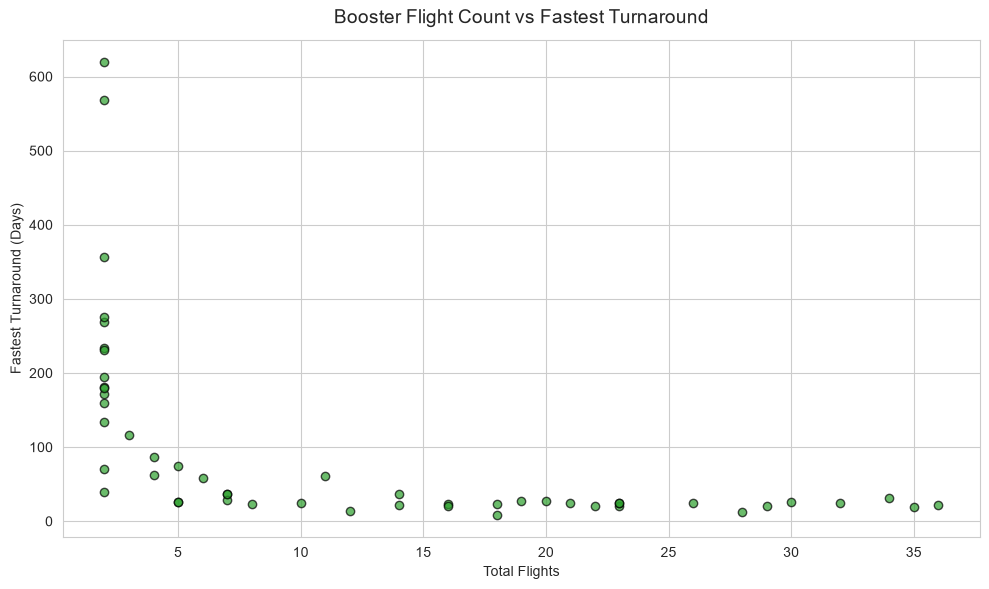

Correlation between flights and fastest turnaround:
                         total_flights  fastest_turnaround_days
total_flights                    1.000                   -0.531
fastest_turnaround_days         -0.531                    1.000


In [18]:
# ============================================================
# REUSE vs TURNAROUND
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(boosters["total_flights"], boosters["fastest_turnaround_days"],
            alpha=0.7, color="#2ca02c", edgecolor="black")
plt.title("Booster Flight Count vs Fastest Turnaround", fontsize=14, pad=12)
plt.xlabel("Total Flights")
plt.ylabel("Fastest Turnaround (Days)")
plt.tight_layout()
plt.show()

print("Correlation between flights and fastest turnaround:")
print(boosters[["total_flights", "fastest_turnaround_days"]].corr().round(3))

In [19]:
# ============================================================
# CAPACITY PRESSURE INDICATORS
# ============================================================

print("=== CAPACITY PRESSURE INDICATORS ===")

# 1. Starlink share (already calculated)
latest_year = annual_share["year"].max()
latest_share = annual_share.loc[annual_share["year"] == latest_year, "starlink_share_pct"].values[0]

# 2. Fleet concentration
top11_share = 50  # approximate from earlier analysis
top23_share = 80

# 3. High-reuse boosters still active
active_high_reuse = boosters[
    (boosters["total_flights"] >= 20) & 
    (boosters["status"] == "active")
]

print(f"Latest Starlink share ({latest_year}): {latest_share}%")
print(f"Boosters accounting for ~50% of flights: 11")
print(f"Boosters accounting for ~80% of flights: 23")
print(f"Active boosters with ≥20 flights: {len(active_high_reuse)}")

=== CAPACITY PRESSURE INDICATORS ===
Latest Starlink share (2026): 76.3%
Boosters accounting for ~50% of flights: 11
Boosters accounting for ~80% of flights: 23
Active boosters with ≥20 flights: 8


In [20]:
# ============================================================
# INVESTIGATE 0-FLIGHT BOOSTERS
# ============================================================

print("=== BOOSTERS WITH 0 FLIGHTS ===")
zero_flight = boosters[boosters["total_flights"] == 0]
print(f"Number of boosters with 0 flights: {len(zero_flight)}")
display(zero_flight[["booster_serial", "total_flights", "status", "first_launch_date", "last_launch_date"]])

=== BOOSTERS WITH 0 FLIGHTS ===
Number of boosters with 0 flights: 2


,booster_serial,total_flights,status,first_launch_date,last_launch_date
84,B1104,0.0,active,NaT,NaT
85,B1102,0.0,active,NaT,NaT


In [21]:
# ============================================================
# LAUNCH vs BOOSTER RECONCILIATION
# ============================================================

print("=== DATASET RECONCILIATION ===")
print(f"Historical Falcon 9 launches     : {len(launches)}")
print(f"Total flights recorded in boosters: {boosters['total_flights'].sum():.0f}")
print(f"Difference                       : {len(launches) - boosters['total_flights'].sum():.0f}")
print("\nNote: Difference is expected if some launches lack identifiable booster records.")
print("This gap should be treated as a data coverage limitation, not an error.")

=== DATASET RECONCILIATION ===
Historical Falcon 9 launches     : 680
Total flights recorded in boosters: 655
Difference                       : 25

Note: Difference is expected if some launches lack identifiable booster records.
This gap should be treated as a data coverage limitation, not an error.


In [22]:
# ============================================================
# TURNAROUND BY FLIGHT STAGE
# ============================================================

print("=== TURNAROUND BY FLIGHT STAGE ===")

def flight_stage(flights):
    if pd.isna(flights):
        return "Unknown"
    if flights <= 5:
        return "1-5"
    elif flights <= 10:
        return "6-10"
    elif flights <= 15:
        return "11-15"
    elif flights <= 20:
        return "16-20"
    elif flights <= 25:
        return "21-25"
    else:
        return "26+"

boosters["flight_stage"] = boosters["total_flights"].apply(flight_stage)

stage_summary = boosters.groupby("flight_stage").agg(
    boosters=("booster_serial", "count"),
    median_turnaround=("fastest_turnaround_days", "median"),
    mean_turnaround=("fastest_turnaround_days", "mean"),
    min_turnaround=("fastest_turnaround_days", "min")
).reindex(["1-5", "6-10", "11-15", "16-20", "21-25", "26+"])

display(stage_summary.round(1))

=== TURNAROUND BY FLIGHT STAGE ===


,boosters,median_turnaround,mean_turnaround,min_turnaround
flight_stage,,,,
1-5,57,172.0,194.0,26.0
6-10,6,32.5,34.7,23.0
11-15,4,29.5,33.5,14.0
16-20,6,23.0,21.7,9.0
21-25,5,24.0,23.2,21.0
26+,8,23.0,22.6,13.0


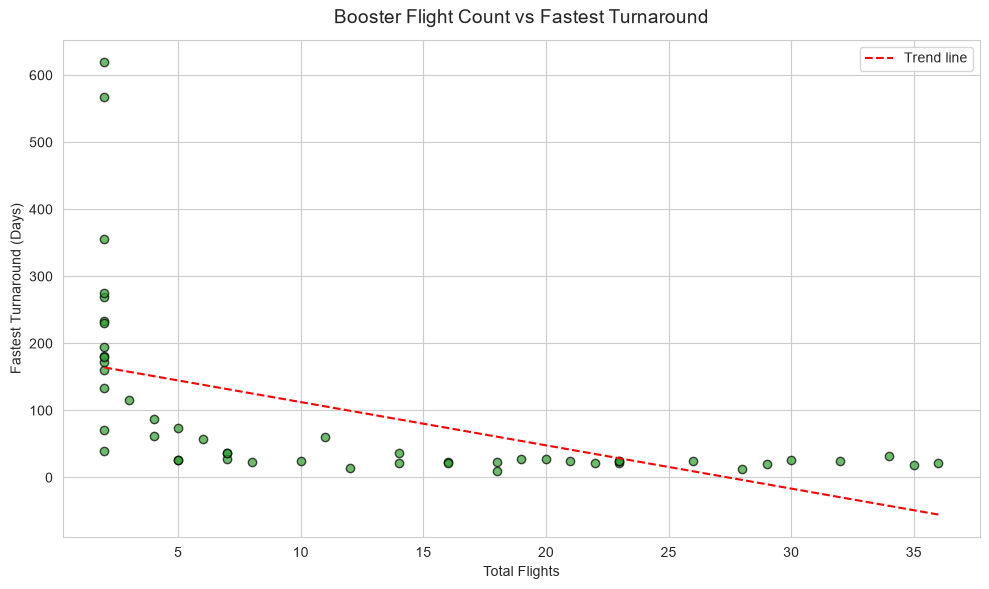

In [23]:
# ============================================================
# SCATTER: FLIGHT COUNT vs FASTEST TURNAROUND
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(boosters["total_flights"], boosters["fastest_turnaround_days"],
            alpha=0.7, color="#2ca02c", edgecolor="black")

# Simple trend line
valid = boosters[["total_flights", "fastest_turnaround_days"]].dropna()
if len(valid) > 2:
    z = np.polyfit(valid["total_flights"], valid["fastest_turnaround_days"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid["total_flights"].min(), valid["total_flights"].max(), 100)
    plt.plot(x_line, p(x_line), "r--", label="Trend line")

plt.title("Booster Flight Count vs Fastest Turnaround", fontsize=14, pad=12)
plt.xlabel("Total Flights")
plt.ylabel("Fastest Turnaround (Days)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Exclude zero-flight records from historical reuse analysis
df_boosters_reuse = boosters[boosters["total_flights"] > 0].copy()

print(f"Boosters used for reuse analysis: {len(df_boosters_reuse)}")
print("Note: 2 active booster records with 0 flights were excluded from historical reuse metrics.")

Boosters used for reuse analysis: 84
Note: 2 active booster records with 0 flights were excluded from historical reuse metrics.


In [25]:
booster_coverage = 655 / 680 * 100
print(f"Booster-linked launch coverage: {booster_coverage:.1f}%")
print("25 Falcon 9 launch records could not be matched to the available booster-level dataset.")

Booster-linked launch coverage: 96.3%
25 Falcon 9 launch records could not be matched to the available booster-level dataset.


## Notebook 03 – Preliminary Findings

### 1. Falcon 9 Cadence
Falcon 9 launch activity has increased substantially over the historical period, reaching 165 launches in 2025. The 2026 figure is year-to-date and should be annualized before direct comparison with completed years.

### 2. Starlink Capacity Allocation
Starlink represents an increasing share of observed Falcon 9 launches, reaching 76.3% in the 2026 year-to-date dataset. This indicates rising internal demand for Falcon 9 capacity.

### 3. Booster Reusability
The booster dataset contains 86 identified boosters, with a maximum recorded flight count of 36. The mean flight count (7.6) is substantially above the median (2), indicating a strongly skewed distribution in which a relatively small number of boosters account for a large proportion of flights.

Two active booster records with 0 flights and no launch dates were excluded from historical reuse metrics.

### 4. Fleet Concentration
Approximately 11 boosters account for 50% of recorded booster flights, while approximately 23 account for 80%. This indicates significant concentration of utilization within a subset of the Falcon 9 fleet.

### 5. Turnaround
Median turnaround decreases substantially from the 1–5 flight stage to higher flight stages and remains approximately 23–24 days for boosters with 16+ flights. No obvious increase in turnaround time is observed among the highest-flight boosters in the current dataset.

However, high-flight groups contain relatively few boosters, and turnaround is influenced by historical operating conditions, mission requirements, and launch scheduling. These results should be interpreted as observational rather than causal.

### 6. Data Coverage
655 booster-linked flights can be associated with 680 historical Falcon 9 launches, giving approximately **96.3%** booster-level coverage. The remaining 25 launches should be treated as unmatched records rather than assumed to represent missing physical boosters.

### Emerging Business Question
The results suggest that Falcon 9’s current challenge may be less about the basic ability to reuse boosters and more about how rapidly growing launch demand and increasing Starlink utilization interact with finite launch-system capacity.

This requires further investigation of external customer demand, launch scheduling, infrastructure constraints, and the Starship transition.